# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc32"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596]] [[0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602]] [[0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619]] ... [[33.567 33.567 33.567 ... 44.841 44.413000000000004 43.985] [33.567 33.567 33.567 ... 44.840999999999994 44.413 43.985] [33.567 33.567 33.567 ... 44.039 44.413 43.985] [33.567 33.567 33.567 ... 46.339666666666666 45.162333333333336 43.985] [33.567 33.567 33.567 ... 45.590333333333334 44.413 43.985] [33.567 33.567 33.567 ... 44.841 44.413 43.985]] [[33.997 33.997 33.997 ... 45.60733333333334 45.32266666666667 45.038] [33.997 33.997 33.997 ... 45.60733333333333 45.32266666666666 45.038] [33.997 33.997 33.997 ... 45.2 45.32266666666666 45.038] [33.997 33.997 33.997 ... 46.96333333333334 46.00066666666667 45.038] [33.997 33.997 33.997 ... 46.285333333333334 45.32266666666666 45.038] [33.997 33.997 33.997 ... 45.60733333333334 45.32266666666666 45.038]] [[33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.7335 46.382333333333335 46.383] [33.935 33.935 33.935 ... 47.08533333333333 46.73416666666667 46.383] [33.935 33.935 33.935 ... 46.7335 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596] [0.837 0.837 0.837 ... 1.596 1.596 1.596]] [[0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602] [0.879 0.879 0.879 ... 1.602 1.602 1.602]] [[0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619] [0.895 0.895 0.895 ... 1.619 1.619 1.619]] ... [[33.567 33.567 33.567 ... 44.841 44.413000000000004 43.985] [33.567 33.567 33.567 ... 44.840999999999994 44.413 43.985] [33.567 33.567 33.567 ... 44.039 44.413 43.985] [33.567 33.567 33.567 ... 46.339666666666666 45.162333333333336 43.985] [33.567 33.567 33.567 ... 45.590333333333334 44.413 43.985] [33.567 33.567 33.567 ... 44.841 44.413 43.985]] [[33.997 33.997 33.997 ... 45.60733333333334 45.32266666666667 45.038] [33.997 33.997 33.997 ... 45.60733333333333 45.32266666666666 45.038] [33.997 33.997 33.997 ... 45.2 45.32266666666666 45.038] [33.997 33.997 33.997 ... 46.96333333333334 46.00066666666667 45.038] [33.997 33.997 33.997 ... 46.285333333333334 45.32266666666666 45.038] [33.997 33.997 33.997 ... 45.60733333333334 45.32266666666666 45.038]] [[33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.7335 46.382333333333335 46.383] [33.935 33.935 33.935 ... 47.08533333333333 46.73416666666667 46.383] [33.935 33.935 33.935 ... 46.7335 46.382333333333335 46.383] [33.935 33.935 33.935 ... 46.38166666666667 46.382333333333335 46.383]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc32' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[ 1.827       1.886       1.924      ...  1.91        1.78
     1.75      ]
   [ 1.94        1.65        1.89       ...  2.1275      2.1875
     2.08      ]
   [ 2.545       2.405       2.43       ...  2.81        3.075
     3.05      ]
   ...
   [19.1165     19.56       19.976      ... 23.124      22.5235
    22.193     ]
   [22.391      26.59       27.089      ... 30.122      30.516
    30.557     ]
   [41.233      41.706      30.815      ... 33.567      33.997
    33.935     ]]

  [[ 1.827       1.886       1.924      ...  2.044       1.96333333
     1.94666667]
   [ 2.078       1.882       1.9835     ...  2.21033333  2.2595
     2.20566667]
   [ 2.56633333  2.49983333  2.42333333 ...  2.92266667  3.13433333
     3.13233333]
...
   [28.26466667 28.56858333 28.95086111 ... 31.30083333 32.21225
    32.87191667]
   [36.26766667 36.435      36.59466667 ... 39.336      40.29933333
    40.391     ]
   [40.91433333 41.208      41.40766667 ... 44.413      45.32266667
    46.38233333]]

  [[ 3.116       3.188       3.254      ...  3.573       3.754
     3.771     ]
   [ 3.817       3.83        3.48       ...  3.045       3.015
     3.21      ]
   [ 4.12        3.77        4.04       ...  5.723       5.877
     6.093     ]
   ...
   [28.90816667 29.3045     29.873      ... 31.766125   32.50525
    33.55925   ]
   [36.188      36.321      36.413      ... 38.961      40.189
    40.193     ]
   [40.755      40.959      41.117      ... 43.985      45.038
    46.383     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 44.841 45.60733333333334 46.38166666666667] [3.116 3.188 3.254 ... 44.413000000000004 45.32266666666667 46.382333333333335] [3.116 3.188 3.254 ... 43.985 45.038 46.383]] [[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 44.840999999999994 45.60733333333333 46.38166666666667] [3.116 3.188 3.254 ... 44.413 45.32266666666666 46.382333333333335] [3.116 3.188 3.254 ... 43.985 45.038 46.383]] [[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 44.039 45.2 46.7335] [3.116 3.188 3.254 ... 44.413 45.32266666666666 46.382333333333335] [3.116 3.188 3.254 ... 43.985 45.038 46.383]] [[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 46.339666666666666 46.96333333333334 47.08533333333333] [3.116 3.188 3.254 ... 45.162333333333336 46.00066666666667 46.73416666666667] [3.116 3.188 3.254 ... 43.985 45.038 46.383]] [[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 45.590333333333334 46.285333333333334 46.7335] [3.116 3.188 3.254 ... 44.413 45.32266666666666 46.382333333333335] [3.116 3.188 3.254 ... 43.985 45.038 46.383]] [[1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] [1.827 1.886 1.924 ... 33.567 33.997 33.935] ... [3.116 3.188 3.254 ... 44.841 45.60733333333334 46.38166666666667] [3.116 3.188 3.254 ... 44.413 45.32266666666666 46.382333333333335] [3.116 3.188 3.254 ... 43.985 45.038 46.383]]]
Units,ppt


### Longitudinal-mean

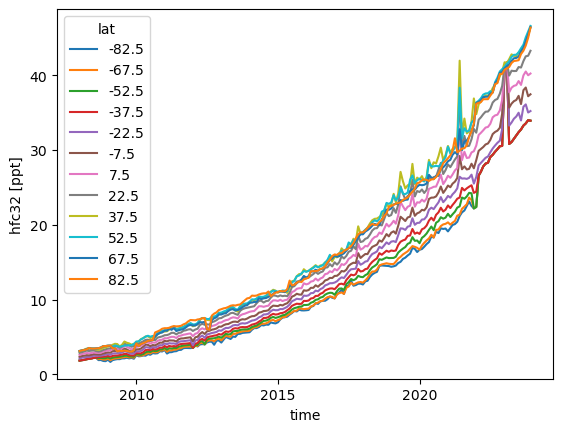

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

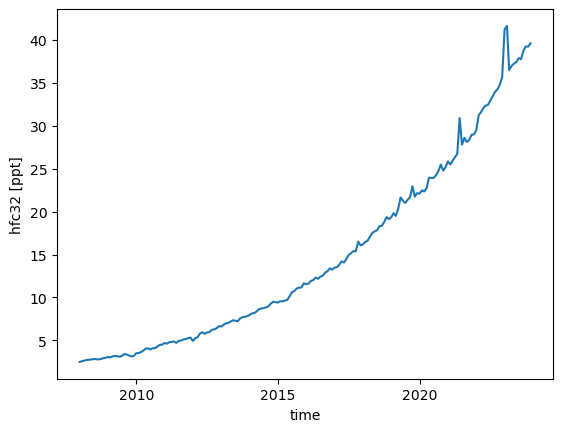

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

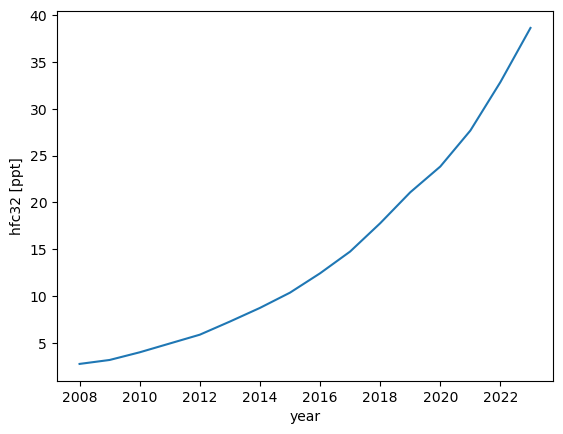

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4173 0.5139 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -2.003 0.2096 ... 3.51e-17

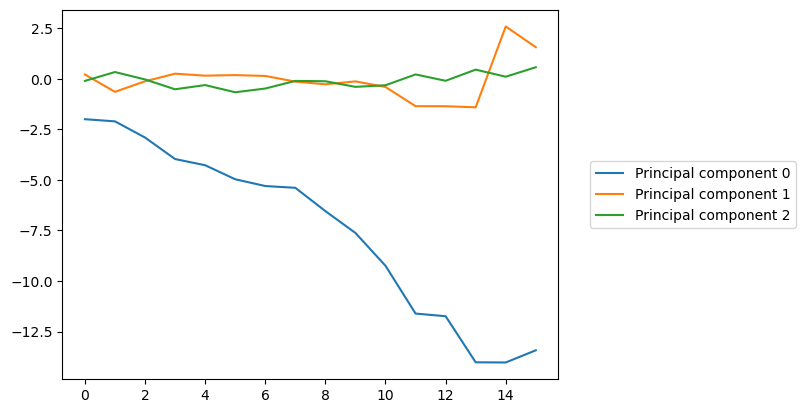

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

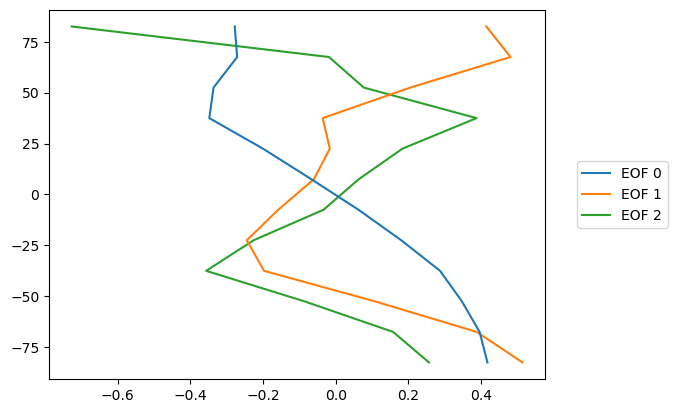

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

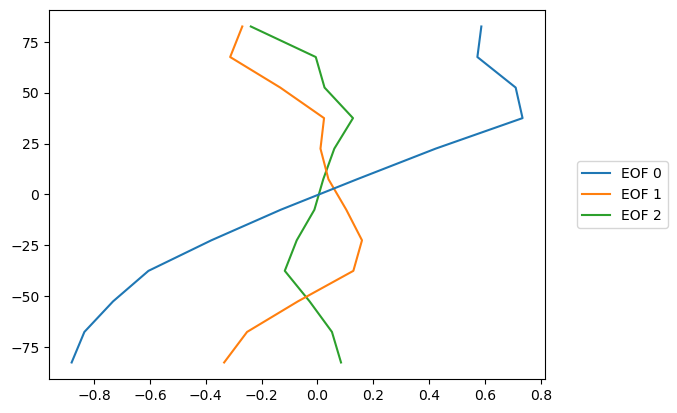

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.41734036455192] [0.39571197620118537] [0.3470349534847473] [0.2869116751472529] [0.18017496829676355] [0.062423403507356354] [-0.06737888261904079] [-0.20043064363070784] [-0.34811458301532805] [-0.33642929097609686] [-0.2714350527775809] [-0.278154647425285]]
Units,ppt
Magnitude,[[-2.0034139520970697] [-2.109325706526569] [-2.909057722192131] [-3.972610468201547] [-4.2788870434570345] [-4.972275154046402] [-5.30731568239616] [-5.394994885383706] [-6.547297253939822] [-7.627516277375989] [-9.250211036333862] [-11.613214742030603] [-11.744591439979397] [-14.023405170115032] [-14.031573847808199] [-13.429028530575751]]
Units,dimensionless


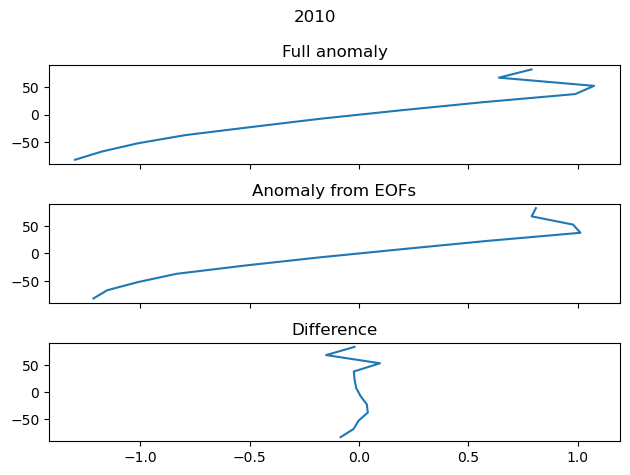

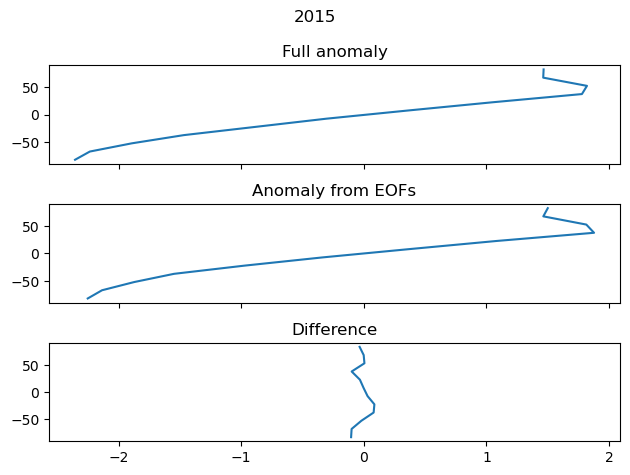

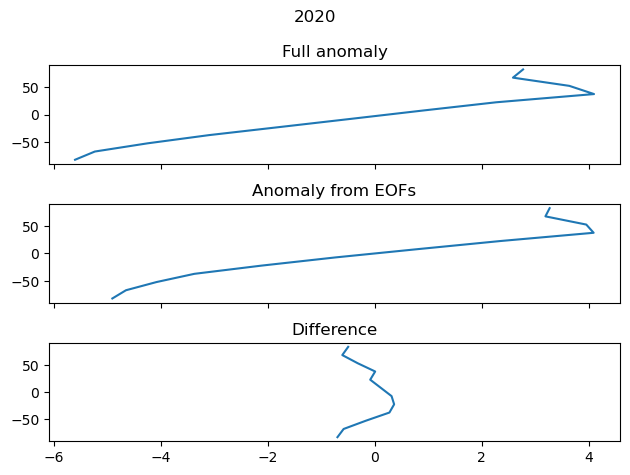

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 9297.75it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19690.12it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 20075.44it/s]

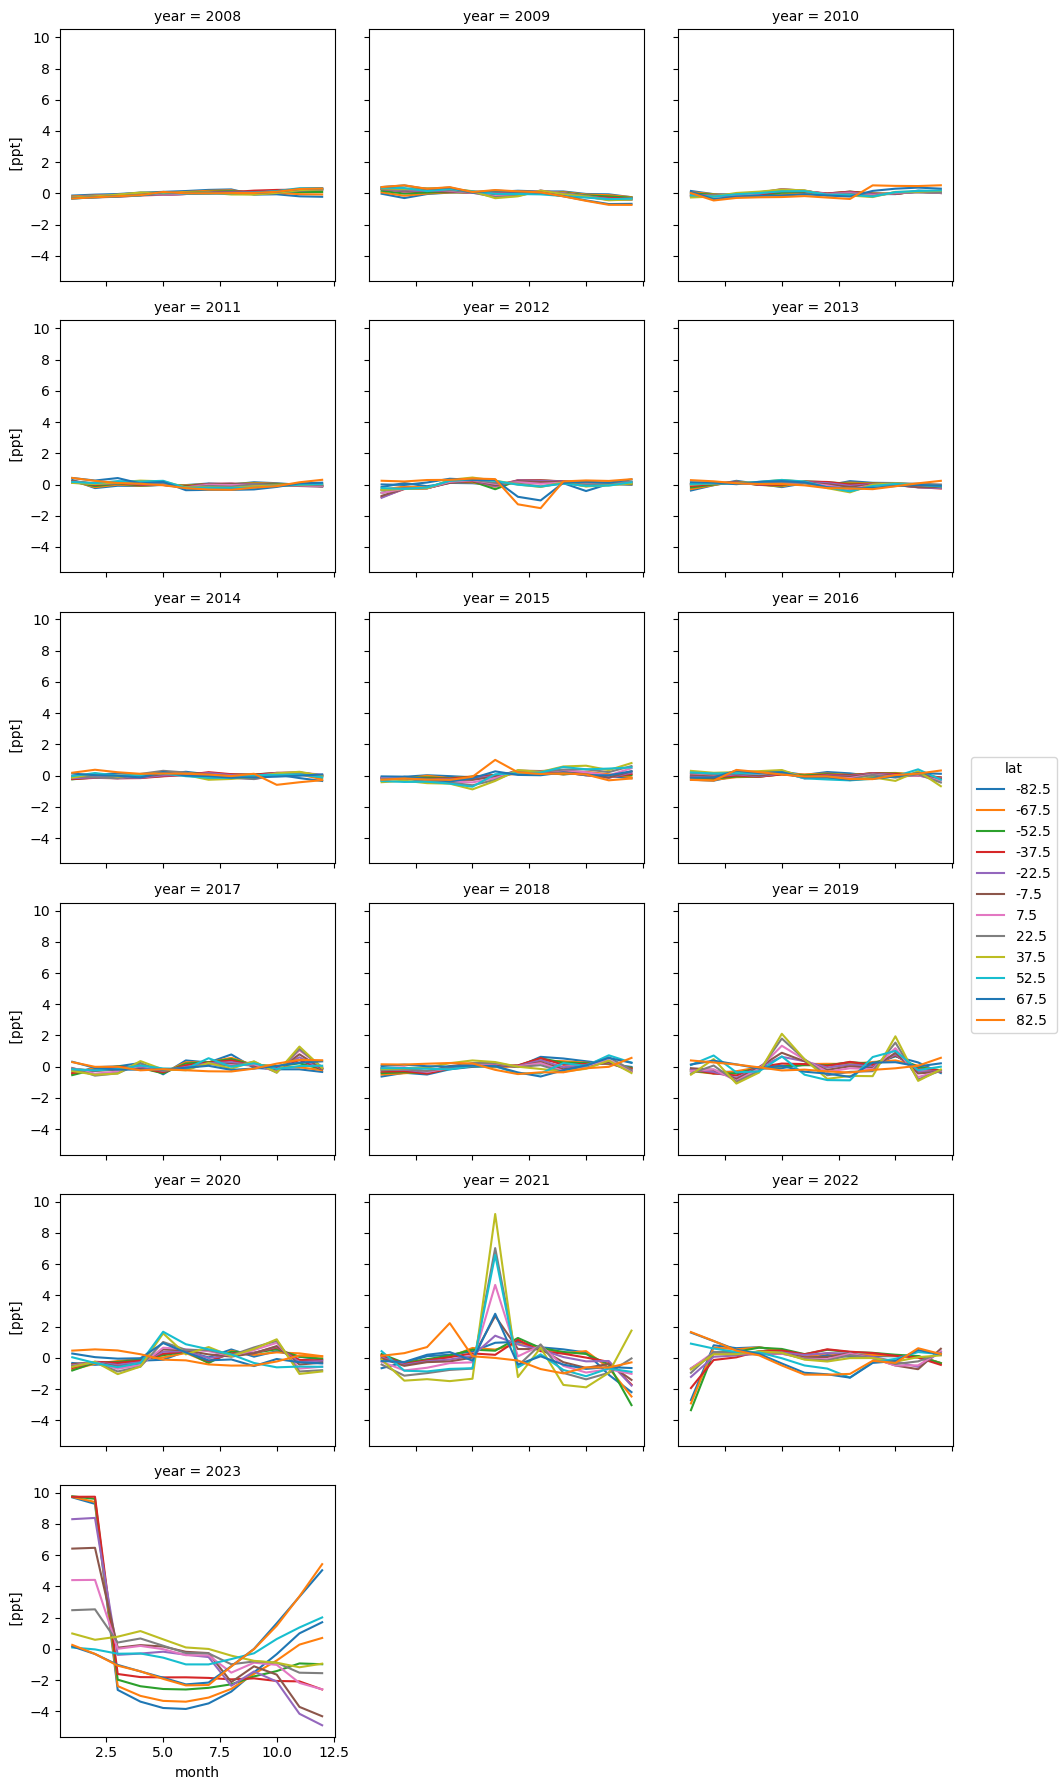

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

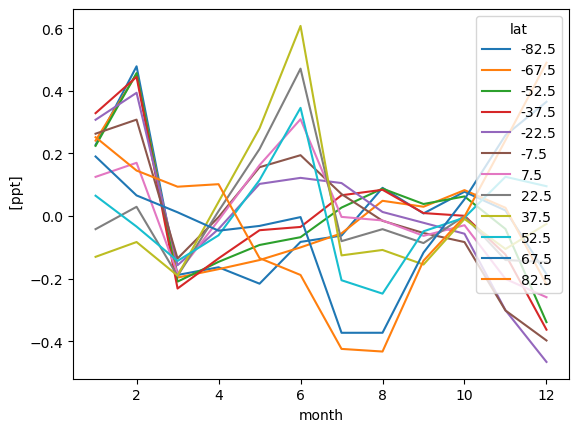

In [22]:
seasonality.plot.line(hue="lat")

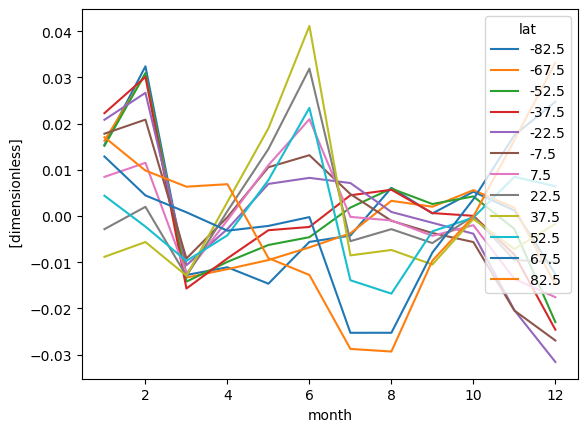

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[2.7411775845836157 3.1637634907431313 3.9827450765682144 4.923919159261726 5.8644700694702685 7.266065583731113 8.725391214378847 10.3554583646615 12.42222320251878 14.747133169952342 17.76978742499544 21.076221064799967 23.8301173401842 27.673901835601583 32.85507974326454 38.63838903007212]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.41734036455192] [0.39571197620118537] [0.3470349534847473] [0.2869116751472529] [0.18017496829676355] [0.062423403507356354] [-0.06737888261904079] [-0.20043064363070784] [-0.34811458301532805] [-0.33642929097609686] [-0.2714350527775809] [-0.278154647425285]]
Units,ppt
Magnitude,[[-2.0034139520970697] [-2.109325706526569] [-2.909057722192131] [-3.972610468201547] [-4.2788870434570345] [-4.972275154046402] [-5.30731568239616] [-5.394994885383706] [-6.547297253939822] [-7.627516277375989] [-9.250211036333862] [-11.613214742030603] [-11.744591439979397] [-14.023405170115032] [-14.031573847808199] [-13.429028530575751]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.015399159093736941 0.03241478580108604 -0.0127639021361058 -0.011096782974500412 -0.01465053795760818 -0.0056025472857978665 -0.004236330406883965 0.006103308999864207 0.0005641599642143934 0.005258650652291249 0.0011990806875911168 -0.012588756470579946] [0.01632532793054941 0.030721397240596724 -0.01332896786069408 -0.011505677236966383 -0.009531827099315394 -0.00679148850015221 -0.0037482833051555556 0.003294723725925772 0.002011092220325362 0.005604507078650628 0.001786035669459571 -0.014836678829972614] [0.015198809212274046 0.030947006304105764 -0.014200586282828576 -0.009924657348075619 -0.006270480818862152 -0.00458212885439977 0.0018270580525728837 0.005938418870662052 0.0026015693129892016 0.004247509226578354 -0.0028057473419978657 -0.022976821750276395] [0.022271712067735337 0.03012179135190242 -0.015696786578490884 -0.009169384764716206 -0.0030747134908604068 -0.0023647449496796325 0.004495183234074433 0.005683417630443364 0.0006361967130582924 4.350362740559223e-05 -0.008340863718350182 -0.024605568263667003] [0.020838269753035352 0.02667934942355239 -0.010651895624639288 -0.002808772414400281 0.006954038612628602 0.008262529654744515 0.0071367635939731605 0.0008780033335419662 -0.0014655937784438678 -0.00383071808414307 -0.02040305553434244 -0.03158939537599481] [0.017826555489089752 0.020869934224131338 -0.009190951131018185 -0.00024101971496839753 0.010565982770267268 0.013170607316458202 0.004752826570516064 -0.0010332374382493775 -0.0036756921546201734 -0.005641338251076869 -0.02045710049694595 -0.02694701232163635] [0.008475235361502286 0.011521774437421965 -0.012457295998393415 -0.0009033036991330336 0.011016436436447539 0.020964994420178452 -0.00018715147671673603 -0.0009574426915383867 -0.0042887866620816345 -0.001990478081769865 -0.013616275708875974 -0.017578050989373817] [-0.002841085223440686 0.0019945601473409127 -0.01298444757336311 0.001062732378501796 0.01450670159030042 0.03190541987751755 -0.005442699270969287 -0.002843138222405164 -0.005857000641982745 -9.4311706163695e-06 -0.009525670132070894 -0.009966308266458168] [-0.008836331460047687 -0.005629103273820032 -0.012900632269351385 0.00305778318480678 0.018994910942891685 0.041159583265388336 -0.008522400142473746 -0.007346222479590367 -0.010501768986464936 -0.0006321894487170911 -0.007140749469437207 -0.0017033253793720044] [0.004395353821732313 -0.002288053355718267 -0.009721970778121036 -0.0041723101154650085 0.007781767452308517 0.023419953644291155 -0.013903780618336947 -0.016804698434711135 -0.0033097623715829367 -0.0003385200864604163 0.008490771296167715 0.006451156545760199] [0.012887021305185688 0.004458998579601275 0.0008098488575650598 -0.0031737368051490047 -0.002142202099544778 -0.00023179197931996108 -0.025282923033321227 -0.025276760551226466 -0.007916613347040625 0.0036337218553968527 0.017498441069623064 0.02473625174524207] [0.01706606050803533 0.009845755194929891 0.006347544931627218 0.0068923133870401635 -0.009115612529760325 -0.012764281917233463 -0.02877148694056731 -0.029340041416832198 -0.009666904238297854 -0.00010658190914039447 0.016421488412995847 0.033192015123654266]]
Units,dimensionless
